# Final Examination: TranslateAI Ancient Character Recognition

Total Marks: 100

**Instructions:**
1. Enter your course email in the cell below.
2. Read the story and problem descriptions carefully.
3. Complete the code in cells containing `# YOUR CODE HERE`. Do not modify the test cells.
4. Run all cells sequentially to ensure your tests pass before submitting.

In [ ]:
# Enter your course email here
student_email = "md.tuhin42525@gmailcom"
print(student_email)

md.tuhin42525@gmailcom


---

## 📖 TranslateAI — Digitizing History

You have just been hired as a Machine Learning Engineer at **TranslateAI**, a startup working with international museums. Your first task is to build a neural network that can automatically classify ancient Japanese cursive texts.

We will use the **KMNIST** dataset — 28x28 grayscale images of 10 cursive characters: *o, ki, su, tsu, na, ha, ma, ya, re, wo*.

To ensure top performance, you must optimize your deep learning pipeline using **Batch Normalization** and **Advanced Optimizers (Adam)**.

---

## Question 1: Load, Explore, & Preprocess Data (20 Marks)

### 1.1 Download the Dataset (5 Marks)

We will use `torchvision.datasets.KMNIST` to download the dataset.

Run the cell below to download the training and test sets:

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Class names for KMNIST
class_names = ['o', 'ki', 'su', 'tsu', 'na', 'ha', 'ma', 'ya', 're', 'wo']

# Download KMNIST
full_train_dataset = torchvision.datasets.KMNIST(root='./data', train=True, download=True)
test_dataset_raw = torchvision.datasets.KMNIST(root='./data', train=False, download=True)

print(f"Training set size: {len(full_train_dataset)}")
print(f"Test set size: {len(test_dataset_raw)}")

Training set size: 60000
Test set size: 10000


### 1.2 Visualize Sample Grayscale Images (5 Marks)

Create a **2x5 subplot figure** (figsize 12x5) showing one sample image from **each of the 10 classes**.
- Title each subplot with its class name
- Turn off axis ticks
- Ensure you use `cmap='gray'` for visualization.

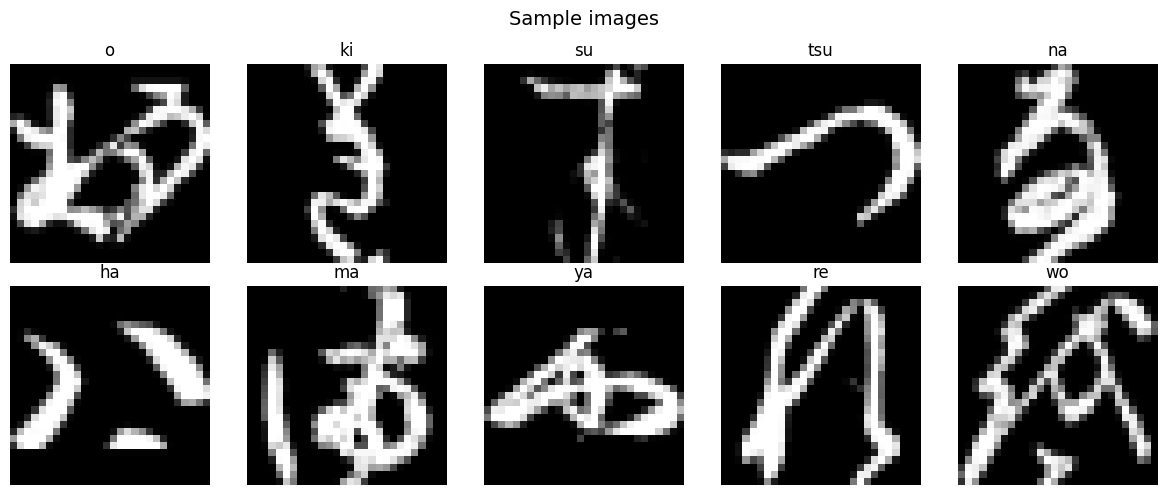

In [ ]:
# YOUR CODE HERE
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
plt.suptitle("Sample images", fontsize = 14)

found = set()

for img, label in full_train_dataset:
    if label not in found:
        ax = axes.flat[label]
        ax.imshow(img, cmap='gray')
        ax.set_title(class_names[label])
        ax.axis('off')
        found.add(label)

    if len(found) == 10:
        break

plt.tight_layout()
plt.show()

### 1.3 Data Scaling & Splitting (10 Marks)

**Your tasks:**
1. Extract images and labels from both train and test datasets as NumPy arrays. (Note: KMNIST images are 28x28)
2. Normalize the pixel values to the range [0, 1] by MinMax Scaling.
3. Split the training data into **train (50,000)** and **validation (10,000)** using `train_test_split` with `random_state=42`.
4. Convert all sets to PyTorch tensors — images as `float32`, labels as `long`.

**Required variables:** `X_train, X_val, X_test` (float32 tensors), `y_train, y_val, y_test` (long tensors)

In [ ]:
X = np.array([np.array(img) for img, label in full_train_dataset])
y = np.array([label for img, label in full_train_dataset])

X_test = np.array([np.array(img) for img, label in test_dataset_raw])
y_test = np.array([label for img, label in test_dataset_raw])

# MinMax Scaling
X = X.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

# Split training data
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=10000, random_state=42
)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype = torch.float32)
X_val = torch.tensor(X_val, dtype = torch.float32)
X_test = torch.tensor(X_test, dtype = torch.float32)

y_train = torch.tensor(y_train, dtype = torch.long)
y_val = torch.tensor(y_val, dtype = torch.long)
y_test = torch.tensor(y_test, dtype = torch.long)

In [ ]:
# --- TEST CELL (DO NOT MODIFY) ---
assert X_train.shape == (50000, 28, 28), f"Expected (50000, 28, 28), got {X_train.shape}"
assert X_val.shape == (10000, 28, 28)
assert X_train.dtype == torch.float32
assert y_train.dtype == torch.long
print("✅ Q1.3 Passed!")

✅ Q1.3 Passed!


---

## Question 2: Build PyTorch DataLoaders (15 Marks)

Create `TensorDataset` and `DataLoader` objects for train, validation, and test sets.

- **batch_size = 256**
- **shuffle = True** for training, **False** for validation and test

**Required variables:** `train_loader`, `val_loader`, `test_loader`

In [ ]:
# YOUR CODE HERE
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

# Dataloaders
train_loader = DataLoader(
    train_dataset, batch_size=256, shuffle=True
)
val_loader = DataLoader(
    val_dataset, batch_size=256, shuffle=False
)
test_loader = DataLoader(
    test_dataset, batch_size=256, shuffle=False
)

In [ ]:
# --- TEST CELL (DO NOT MODIFY) ---
batch_X, batch_y = next(iter(train_loader))
assert batch_X.shape == (256, 28, 28)
assert batch_y.dtype == torch.long
print("✅ Q2 Passed!")

✅ Q2 Passed!


---

## Question 3: Deep Neural Network Architecture (25 Marks)

Create a class `TranslateAIClassifier` inheriting from `nn.Module`.

Use `nn.Sequential` with this architecture. Since the input is `28x28`, the flattened size is **784**.

| Layer | Description |
|-------|-------------|
| Flatten | Convert 28x28 → 784 |
| Linear | 784 → 512 |
| BatchNorm1d | Batch Normalization (512 features) |
| ReLU | Activation |
| Linear | 512 → 256 |
| BatchNorm1d | Batch Normalization (256 features) |
| ReLU | Activation |
| Linear | 256 → 128 |
| BatchNorm1d | Batch Normalization (128 features) |
| ReLU | Activation |
| Linear | 128 → 10 |

After defining the class, create an instance called `model` and print it.

In [ ]:
class TranslateAIClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Flatten(),

            nn.Linear(784, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.model(x)

model = TranslateAIClassifier()
print(model)

TranslateAIClassifier(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Linear(in_features=256, out_features=128, bias=True)
    (8): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [ ]:
# --- TEST CELL (DO NOT MODIFY) ---
test_input = torch.randn(5, 28, 28)
test_output = model(test_input)
assert test_output.shape == (5, 10)
has_batchnorm = any(isinstance(m, nn.BatchNorm1d) for m in model.modules())
assert has_batchnorm, "Model must include BatchNorm1d layers"
print("✅ Q3 Passed!")

✅ Q3 Passed!


---

## Question 4: Advanced Training Pipeline (25 Marks)

### 4.1 Setup Optimizer and Loss (5 Marks)
- Loss function: `nn.CrossEntropyLoss`
- Optimizer: `optim.Adam` with `lr=0.001`
- Number of epochs: **15**

In [ ]:
epochs = 15

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)



### 4.2 PyTorch Training Pipeline (20 Marks)

Write the training loop for **15 epochs**.

For each epoch:
1. Set model to training mode (`model.train()`)
2. Train on `train_loader` (forward pass, calculate loss, backward pass, optimizer step)
3. Set model to evaluation mode (`model.eval()`)
4. Evaluate on `val_loader` and compute validation loss and accuracy.
5. Print: `Epoch {epoch+1}/{epochs} | Train Loss: {:.4f} | Val Loss: {:.4f}`

Store: `train_losses`, `val_losses` lists.

In [ ]:
train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    running_train_loss = 0.0

    for images, labels in train_loader:
        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

    train_loss = running_train_loss / len(train_loader)
    train_losses.append(train_loss)

    # Validation
    model.eval()

    running_val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            outputs = model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = running_val_loss / len(val_loader)
    val_accuracy = 100 * correct / total

    val_losses.append(val_loss)

    print(f"Epoch {epoch+1} / {epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch 1 / 15 | Train Loss: 0.3808 | Val Loss: 0.1833
Epoch 2 / 15 | Train Loss: 0.1335 | Val Loss: 0.1489
Epoch 3 / 15 | Train Loss: 0.0784 | Val Loss: 0.1510
Epoch 4 / 15 | Train Loss: 0.0504 | Val Loss: 0.1307
Epoch 5 / 15 | Train Loss: 0.0352 | Val Loss: 0.1323
Epoch 6 / 15 | Train Loss: 0.0290 | Val Loss: 0.1587
Epoch 7 / 15 | Train Loss: 0.0256 | Val Loss: 0.1293
Epoch 8 / 15 | Train Loss: 0.0183 | Val Loss: 0.1518
Epoch 9 / 15 | Train Loss: 0.0191 | Val Loss: 0.1433
Epoch 10 / 15 | Train Loss: 0.0132 | Val Loss: 0.1378
Epoch 11 / 15 | Train Loss: 0.0102 | Val Loss: 0.1501
Epoch 12 / 15 | Train Loss: 0.0118 | Val Loss: 0.1566
Epoch 13 / 15 | Train Loss: 0.0155 | Val Loss: 0.1484
Epoch 14 / 15 | Train Loss: 0.0133 | Val Loss: 0.1494
Epoch 15 / 15 | Train Loss: 0.0107 | Val Loss: 0.1591


In [ ]:
# --- TEST CELL (DO NOT MODIFY) ---
assert len(train_losses) == 15, f"Expected 15 epochs, got {len(train_losses)}"
assert len(val_losses) == 15
print("✅ Q4.2 Passed!")

✅ Q4.2 Passed!


---

## Question 5: Evaluation & Analytics (10 Marks)

### 5.1 Test Evaluation (5 Marks)
Evaluate the model on the **test set**.
- Print the Test Accuracy.
- Collect Test dataset's all predictions into a list called `all_preds`.

In [ ]:
model.eval()
all_preds = []
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.tolist())

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total
print(f"Test Accuracy: {test_accuracy:.2f}")

Test Accuracy: 91.01


### 5.2 Plot Learning Curves (5 Marks)
Plot **Training Loss** and **Validation Loss** on the same figure across epochs. Include a legend and title.

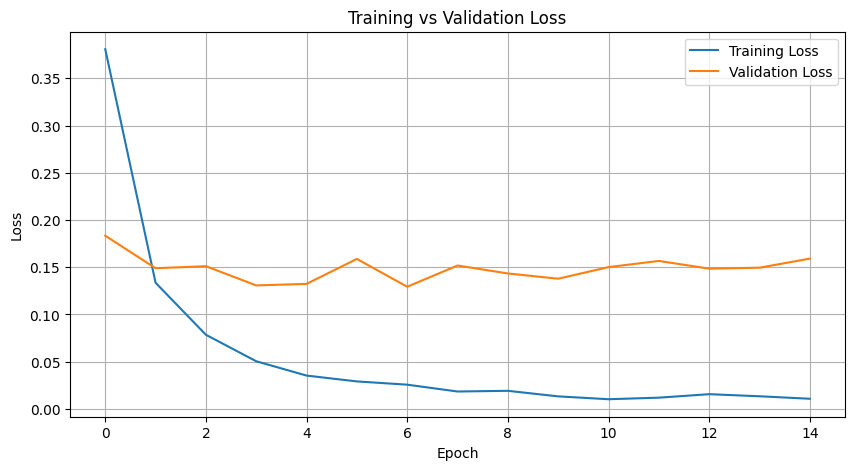

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(train_losses, label = 'Training Loss')
plt.plot(val_losses, label = 'Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### 5.3 Confusion Matrix & Analysis (5+5 Marks)
1. Plot the confusion matrix using `ConfusionMatrixDisplay`.
2. Write a brief markdown explanation of which ancient character classes are most frequently confused by the model based on the matrix.

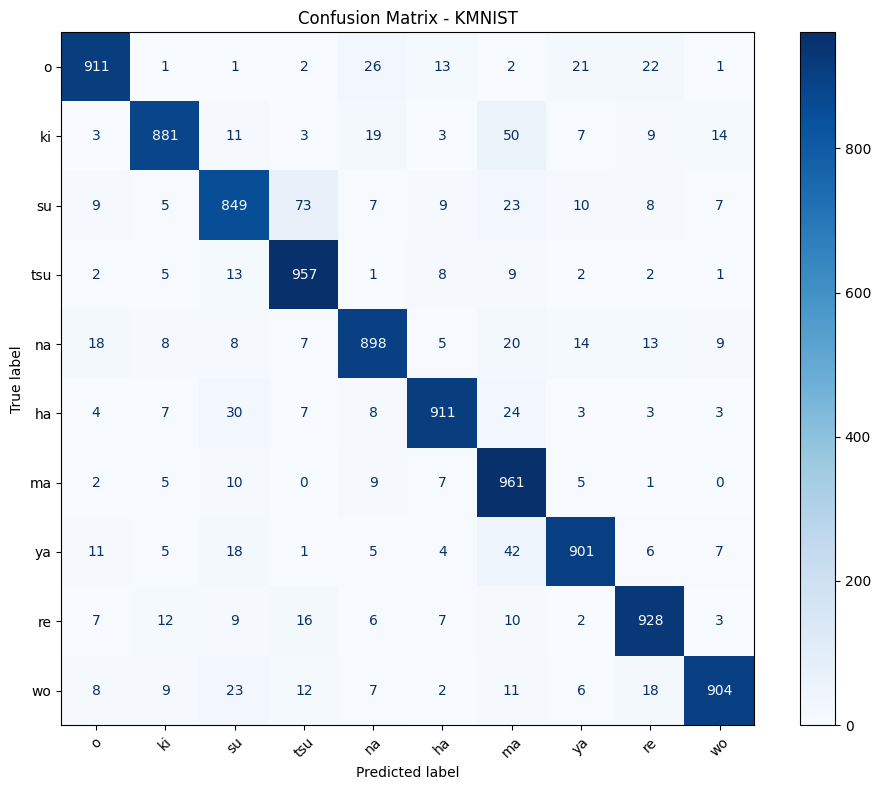

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test.numpy(), all_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels = class_names
)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax = ax, cmap='Blues', xticks_rotation = 45)

plt.title("Confusion Matrix - KMNIST")
plt.tight_layout()
plt.show()



**Your Analysis:**

Confusion Matrix shows that the model performs well on most KMNIST character classes, as the majority of predictions are concentrated along the diagonal.

The most frequntly confused pair is **su** and **tsu**. The model misclassified **73 `su` samples as `tsu`**, which is the highest off-diagonal value in the confusion matrix. This suggests that these two characters have similar visual patterns, making them difficult for the model to distinguish.

Another notable confusion is **`ki` -> `ma`**, with 50 misclassified samples, followed by **`ya` -> `ma`**, with 42 samples. Overall, the strong diagonal values indicate that the model achives good classification performance across the 10 classes